In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('netflix.csv')

# <span style="color:orange">1. Analyzing Basic Metrics</span>

In [3]:
df.shape

(8807, 12)

In [4]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


# <span style="color:orange">2. Initial Obervations</span>

In [32]:
# Shape of data

In [10]:
df.shape

(8807, 12)

In [31]:
# Type of data

In [11]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [30]:
# Data types Conversion

In [19]:
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')

In [26]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [27]:
df.dtypes

show_id                    str
type                  category
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                category
duration                   str
listed_in                  str
description                str
dtype: object

In [29]:
# Date Extraction for further analysis

In [44]:
df['year_added'] = df['date_added'].dt.year
df['year_added'] = df['year_added'].astype('Int64')
df['month_added'] = df['date_added'].dt.month_name()

In [38]:
list(df.columns)

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description',
 'year_added',
 'month_added']

In [34]:
# Missing Value Detection

In [35]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added        10
month_added       10
dtype: int64

In [36]:
(df.isnull().sum()/len(df)*100).round(2)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
year_added       0.11
month_added      0.11
dtype: float64

In [42]:
# Statistical Summary

In [52]:
round(df['release_year'].describe(),1)

count    8807.0
mean     2014.2
std         8.8
min      1925.0
25%      2013.0
50%      2017.0
75%      2019.0
max      2021.0
Name: release_year, dtype: float64

# <span style="color:orange">3. Non-Graphical Analysis</span>

In [109]:
#Value Counts

In [54]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [55]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
Name: count, dtype: int64

In [59]:
df['country'].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [60]:
df['listed_in'].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

In [61]:
df['director'].value_counts()

director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Peter Hewitt                1
Mozez Singh                 1
Name: count, Length: 4528, dtype: int64

# <span style="color:orange">Data Preprocessing</span>

In [75]:
# Unnesting of columns

In [76]:
df_country = df.assign(country=df['country'].str.split(', ')).explode('country')
df_country['country'] = df_country['country'].str.strip()

In [77]:
df_genre = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')
df_genre['listed_in'] = df_genre['listed_in'].str.strip()

In [80]:
df_actor = df.assign(cast=df['cast'].str.split(', ')).explode('cast')
df_actor['cast'] = df_actor['cast'].str.strip()

In [81]:
df_director = df.assign(director=df['director'].str.split(', ')).explode('director')
df_director['director'] = df_director['director'].str.strip()

In [111]:
df['rating']

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: category
Categories (17, str): ['66 min', '74 min', '84 min', 'G', ..., 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']

In [123]:
# These rows have the movie duration incorrectly stored in the rating column, while duration is NaN.

In [116]:
df[df['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017,April
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016,September
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,2016,August


In [125]:
mask = df['show_id'].isin(['s5542', 's5795', 's5814'])

In [126]:
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = pd.NA

In [130]:
df.loc[df['show_id'] == 's5542', 'duration'] = '74 min'
df.loc[df['show_id'] == 's5795', 'duration'] = '84 min'
df.loc[df['show_id'] == 's5814', 'duration'] = '66 min'

In [180]:
df.loc[
    df['show_id'].isin(['s5542', 's5795', 's5814']),
    ['show_id', 'title', 'rating', 'duration']
]

,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,NaN,74 min
5794,s5795,Louis C.K.: Hilarious,NaN,84 min
5813,s5814,Louis C.K.: Live at the Comedy Store,NaN,66 min


In [183]:
df['rating'] = df['rating'].cat.remove_unused_categories()

In [184]:
df['rating'].cat.categories

Index(['G', 'NC-17', 'NR', 'PG', 'PG-13', 'R', 'TV-14', 'TV-G', 'TV-MA',
       'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR'],
      dtype='str')

In [ ]:
# Extracted numeric duration values into separate columns for movies (minutes) and TV shows (seasons)

In [218]:
# Movies
movies_duration = df[df['type'] == 'Movie'].copy()
movies_duration['duration_min'] = movies_duration['duration'].str.extract(r'(\d+)').astype(int)

In [151]:
# TV Shows
tv_duration = df[df['type'] == 'TV Show'].copy()
tv_duration['seasons'] = tv_duration['duration'].str.extract(r'(\d+)').astype(int)

In [153]:
'duration_min' in movies_duration.columns

True

In [154]:
'seasons' in tv_duration.columns

True

In [84]:
#  Unique Attributes

In [83]:
df_country['country'].nunique()

127

In [85]:
df_genre['listed_in'].nunique()

42

In [86]:
df_actor['cast'].nunique()

36439

In [1]:
# df_actor['cast'].unique().tolist()

In [90]:
df_director['director'].nunique()

4993

In [92]:
df['rating'].value_counts().head()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

In [103]:
(df['rating'].value_counts(normalize=True) * 100).round(1).head()

rating
TV-MA    36.4
TV-14    24.5
TV-PG     9.8
R         9.1
PG-13     5.6
Name: proportion, dtype: float64

In [104]:
df_country['country'].value_counts().head()

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64

In [105]:
(df_country['country'].value_counts(normalize=True) * 100).round(1).head()

country
United States     36.8
India             10.4
United Kingdom     8.0
Canada             4.4
France             3.9
Name: proportion, dtype: float64

In [106]:
df_genre['listed_in'].value_counts().head()

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

In [107]:
df_director['director'].value_counts().head()

director
Rajiv Chilaka    22
Jan Suter        21
Raúl Campos      19
Suhas Kadav      16
Marcus Raboy     16
Name: count, dtype: int64

In [108]:
df_actor['cast'].value_counts().head()

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Name: count, dtype: int64

# <span style="color:orange">4. Visual Analysis</span>

In [132]:
# Univariate Analysis (Continuous Variables)

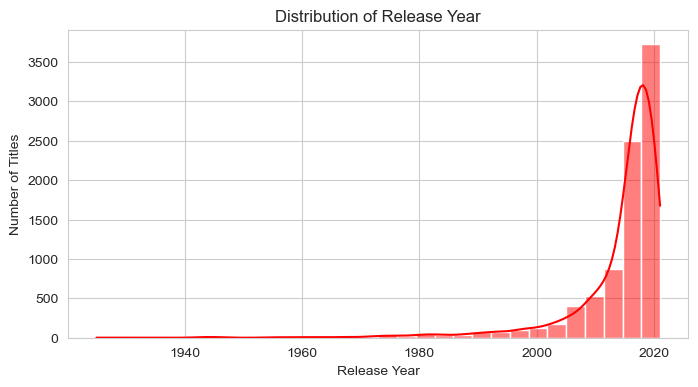

In [197]:
plt.figure(figsize=(8,4))
sns.histplot(df['release_year'], bins=30, kde=True, color='red')

plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.savefig('release_year_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

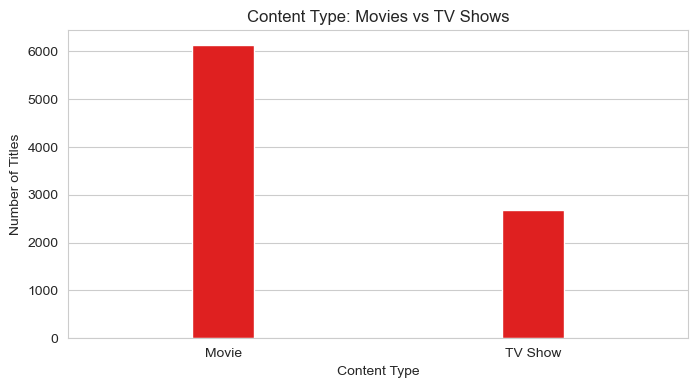

In [189]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='type', color='red', width=0.2)

plt.title('Content Type: Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.savefig('movie_duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

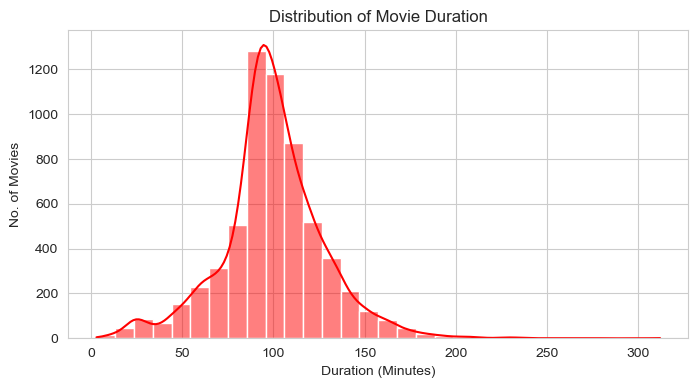

In [198]:
plt.figure(figsize=(8,4))
sns.histplot(movies_duration[movies_duration['type']=='Movie'], x='duration_min', bins=30, kde=True, color='red')

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('No. of Movies')

plt.savefig('movie_duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

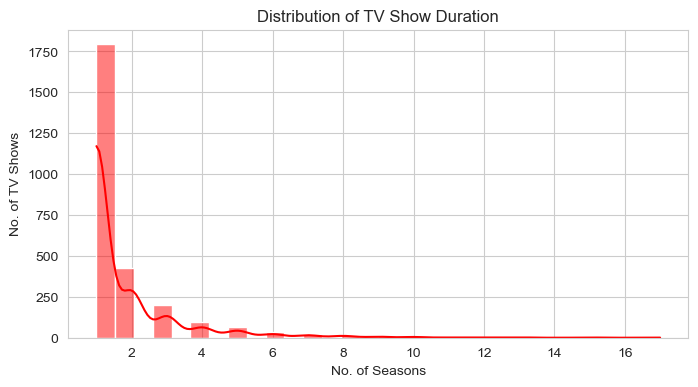

In [199]:
plt.figure(figsize=(8,4))
sns.histplot(tv_duration[tv_duration['type']=='TV Show'], x='seasons', bins=30, kde=True, color='red')

plt.title('Distribution of TV Show Duration')
plt.xlabel('No. of Seasons')
plt.ylabel('No. of TV Shows')

plt.savefig('tv_duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

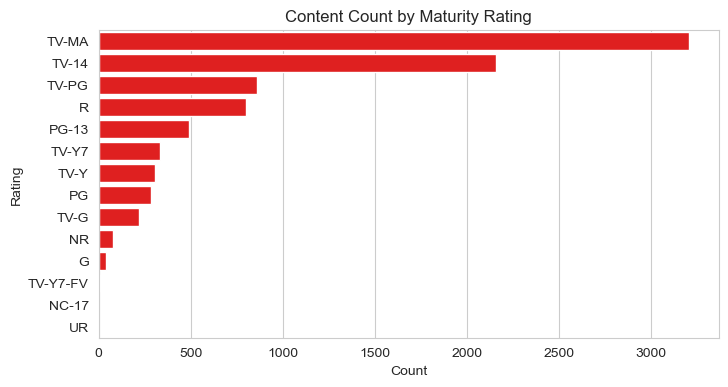

In [196]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, y='rating', color='red', order=df['rating'].value_counts().index)

plt.title('Content Count by Maturity Rating')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.savefig('rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

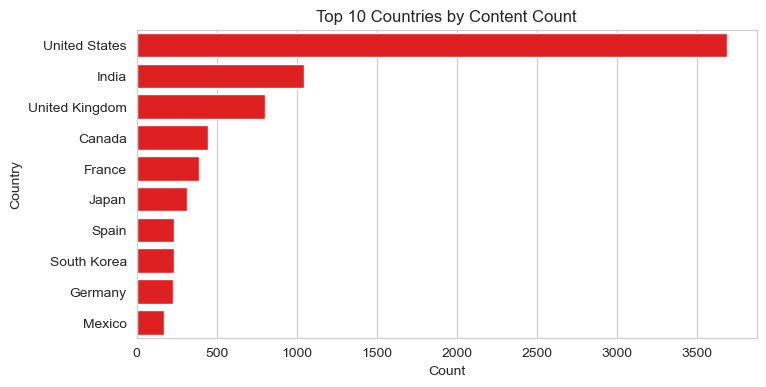

In [206]:
plt.figure(figsize=(8,4))
top10_countries = df_country['country'].value_counts().head(10)
sns.barplot(x=top10_countries.values, y=top10_countries.index, color='red')

plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.ylabel('Country')

plt.savefig('top10_countries.png', dpi=300, bbox_inches='tight')
plt.show()

In [214]:
# Categorical variable

In [225]:
movies_duration['rating'] = (movies_duration['rating'].cat.remove_unused_categories())

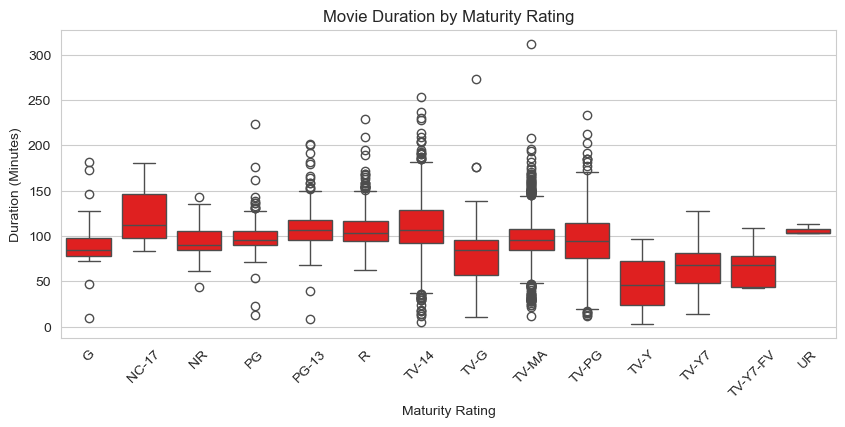

In [245]:
plt.figure(figsize=(10,4))
sns.boxplot(data=movies_duration[movies_duration['type']=='Movie'], x='rating', y='duration_min', color='red')

plt.title('Movie Duration by Maturity Rating')
plt.xlabel('Maturity Rating')
plt.ylabel('Duration (Minutes)')
plt.xticks(rotation=45)

plt.savefig('Movie_Duration_Maturity_Rating.png', dpi=300, bbox_inches='tight')
plt.show()

In [246]:
tv_duration['rating'] = (tv_duration['rating'].cat.remove_unused_categories())

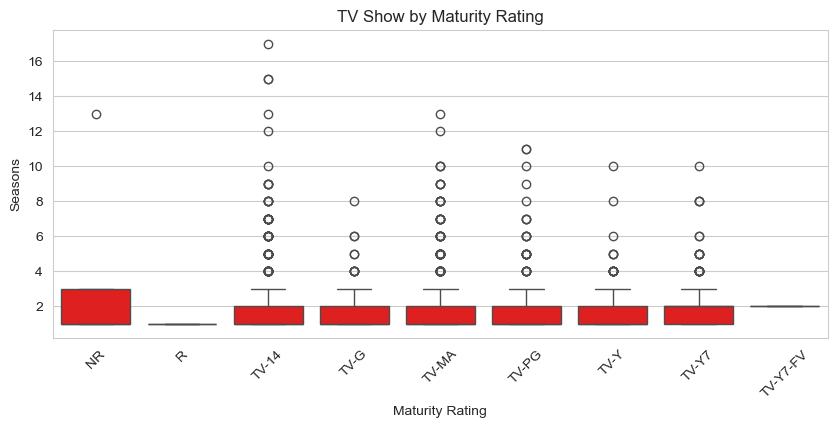

In [252]:
plt.figure(figsize=(10,4))
sns.boxplot(data=tv_duration[tv_duration['type']=='TV Show'], x='rating', y='seasons', color='red')

plt.title('TV Show by Maturity Rating')
plt.xlabel('Maturity Rating')
plt.ylabel('Seasons')
plt.xticks(rotation=45)

plt.savefig('tv_Duration_Maturity_Rating.png', dpi=300, bbox_inches='tight')
plt.show()

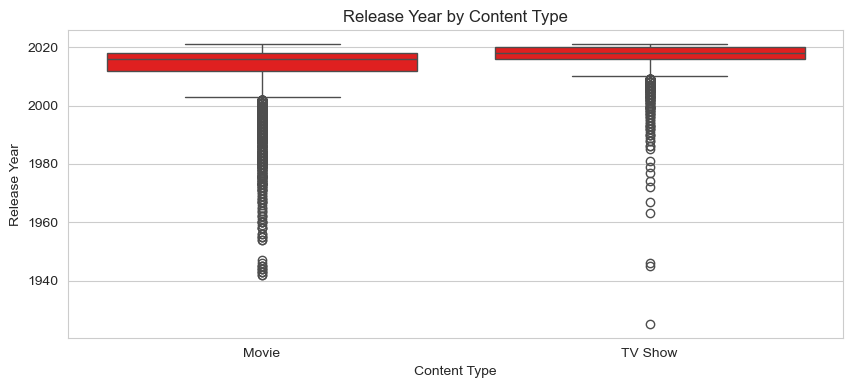

In [260]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='type', y='release_year', color='red')

plt.title('Release Year by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Release Year')

plt.savefig('rel.png', dpi=300, bbox_inches='tight')
plt.show()

# <span style="color:orange">5. Missing Value & Outlier check </span>

In [274]:
df.isnull().sum()

show_id              0
type                 0
title                0
director          2634
cast               825
country            831
date_added          10
release_year         0
rating               7
duration             0
listed_in            0
description          0
year_added          10
month_added         10
duration_value       0
dtype: int64

In [278]:
(df.isnull().sum()/len(df)*100).round(2)

show_id            0.00
type               0.00
title              0.00
director          29.91
cast               9.37
country            9.44
date_added         0.11
release_year       0.00
rating             0.08
duration           0.00
listed_in          0.00
description        0.00
year_added         0.11
month_added        0.11
duration_value     0.00
dtype: float64

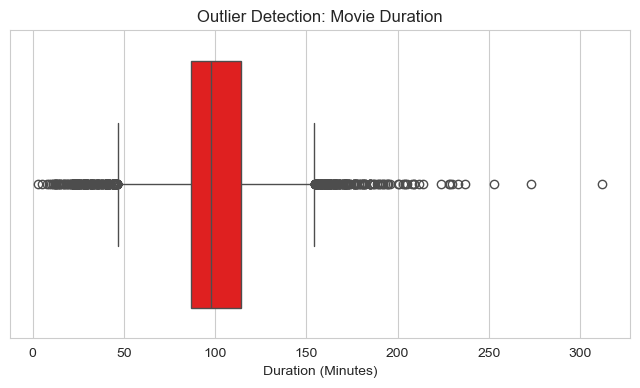

In [280]:
plt.figure(figsize=(8,4))

sns.boxplot(x=movies_duration['duration_min'],color='red')

plt.title('Outlier Detection: Movie Duration')
plt.xlabel('Duration (Minutes)')

plt.savefig('movie_outlier.png', dpi=300, bbox_inches='tight')
plt.show()

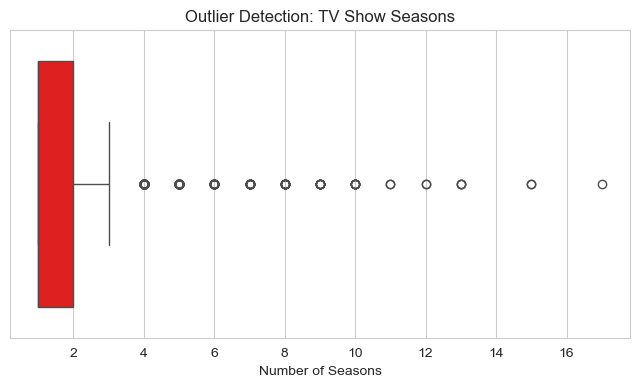

In [281]:
plt.figure(figsize=(8,4))

sns.boxplot(x=tv_duration['seasons'],color='red')

plt.title('Outlier Detection: TV Show Seasons')
plt.xlabel('Number of Seasons')

plt.savefig('tv_outlier.png', dpi=300, bbox_inches='tight')
plt.show()